In [1]:
!nvcc --version
!nvidia-smi

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
Wed May  6 11:14:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8       

In [2]:
!pip install -U transformers accelerate bitsandbytes pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 84.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 84.5 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
ERROR: pip's dependency res

## Imports + Config

In [1]:
import os
import gc
import csv
import time
import threading
from dataclasses import dataclass, asdict
from typing import List, Dict, Any

import torch
import pandas as pd
import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TextIteratorStreamer,
    BitsAndBytesConfig,
)

In [2]:
# ============================================================
# Colab T4 Config
# ============================================================

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

RESULT_DIR = "/content/day24_quant_results"
os.makedirs(RESULT_DIR, exist_ok=True)

CSV_PATH = os.path.join(RESULT_DIR, "benchmark_results.csv")

PROMPTS = [
    "Explain what quantization means for LLM inference in simple terms.",
    "Why can quantization reduce GPU memory usage?",
    "Compare FP16 inference and INT8 inference for large language models.",
    "Write a short paragraph about the trade-off between latency and output quality.",
]

MAX_NEW_TOKENS_LIST = [32, 64, 128]

NUM_WARMUP = 1
NUM_RUNS = 3

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## Result Dataclass

In [3]:
@dataclass
class BenchmarkResult:
    mode: str
    model_name: str
    quantization: str
    prompt_id: int
    prompt_chars: int
    input_tokens: int
    output_tokens: int
    max_new_tokens: int

    ttft_ms: float
    total_latency_ms: float
    tpot_ms: float
    throughput_tok_s: float

    peak_allocated_gb: float
    peak_reserved_gb: float

    output_text: str
    quality_note: str

## Utility Functions

In [4]:
def clear_gpu_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()


def get_peak_memory_gb():
    if not torch.cuda.is_available():
        return 0.0, 0.0

    allocated = torch.cuda.max_memory_allocated() / 1024**3
    reserved = torch.cuda.max_memory_reserved() / 1024**3
    return allocated, reserved


def count_tokens(tokenizer, text: str) -> int:
    if len(text.strip()) == 0:
        return 0
    return len(tokenizer(text, return_tensors="pt")["input_ids"][0])


def save_results_to_csv(results: List[BenchmarkResult], path: str):
    if not results:
        return

    fieldnames = list(asdict(results[0]).keys())

    with open(path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for r in results:
            writer.writerow(asdict(r))

    print(f"Saved results to: {path}")

## Load Model(Todo)

In [5]:
def load_model_and_tokenizer(
    model_name: str,
    quantization: str,
):
    """
    quantization:
    - "fp16"
    - "int8"

    TODO:
    You need to complete the tokenizer and model loading.
    """

    print("=" * 80)
    print(f"Loading model: {model_name}")
    print(f"Quantization mode: {quantization}")
    print("=" * 80)

    clear_gpu_memory()

    # ========================================================
    # TODO 1: Load tokenizer
    # ========================================================
    tokenizer = AutoTokenizer.from_pretrained(model_name,
                                              trust_remote_code=True,)

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    # ========================================================
    # TODO 2: Load model
    # ========================================================
    model = None

    if quantization == "fp16":
        # ----------------------------------------------------
        # TODO:
        # Load FP16 baseline model
        # ----------------------------------------------------
        model = AutoModelForCausalLM.from_pretrained(model_name,
                                                     torch_dtype=torch.float16,
                                                     device_map="auto",
                                                     trust_remote_code=True,)


    elif quantization == "int8":
        # ----------------------------------------------------
        # TODO:
        # Load INT8 quantized model with bitsandbytes
        # ----------------------------------------------------
        bnb_config = BitsAndBytesConfig(load_in_8bit=True,)
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            quantization_config=bnb_config,
            device_map="auto",
            trust_remote_code=True,
        )

    else:
        raise ValueError(f"Unknown quantization mode: {quantization}")

    # ========================================================
    # TODO 3: eval mode
    # ========================================================
    model.eval()

    print("Model loaded.")
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3
        reserved = torch.cuda.memory_reserved() / 1024**3
        print(f"Current allocated memory: {allocated:.3f} GB")
        print(f"Current reserved memory:   {reserved:.3f} GB")

    return tokenizer, model

## Prompt Formatting

In [6]:
def build_prompt(tokenizer, raw_prompt: str) -> str:
    """
    TODO:
    construct prompt using Qwen's chat template.

    Return:
        formatted prompt string
    """

    # ========================================================
    # TODO:
    # apply tokenizer.apply_chat_template
    # ========================================================
    messages = [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": raw_prompt},
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    return prompt


## single inference + TTFT/TPOT measure

In [7]:
@torch.no_grad()
def run_single_inference_streaming(
    tokenizer,
    model,
    raw_prompt: str,
    max_new_tokens: int,
) -> Dict[str, Any]:
    """
    Run one generation and measure:

    - TTFT
    - total latency
    - TPOT
    - throughput
    - peak GPU memory

    Use TextIteratorStreamer to estimate TTFT.
    """

    clear_gpu_memory()

    formatted_prompt = build_prompt(tokenizer, raw_prompt)

    # ========================================================
    # TODO 1: Tokenize input
    # ========================================================
    # inputs = None
    input_tokens = 0

    inputs = tokenizer(
        formatted_prompt,
        return_tensors="pt",
    )

    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    input_tokens = inputs["input_ids"].shape[-1]


    # ========================================================
    # TODO 2: Create streamer
    # ========================================================
    # streamer = None

    streamer = TextIteratorStreamer(
        tokenizer,
        skip_prompt=True,
        skip_special_tokens=True,
    )


    # ========================================================
    # TODO 3: Generation kwargs
    # ========================================================
    generation_kwargs = dict(
        **inputs,
        streamer=streamer,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )


    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start_time = time.perf_counter()
    first_token_time = None
    output_chunks = []

    # ========================================================
    # TODO 4: Start generation in another thread
    # ========================================================
    thread = threading.Thread(
        target=model.generate,
        kwargs=generation_kwargs,
    )
    thread.start()


    # ========================================================
    # TODO 5: Consume streamer and capture TTFT
    # ========================================================
    for new_text in streamer:
        if first_token_time is None:
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            first_token_time = time.perf_counter()

        output_chunks.append(new_text)


    # ========================================================
    # TODO 6: Wait for generation thread
    # ========================================================
    thread.join()


    if torch.cuda.is_available():
        torch.cuda.synchronize()

    end_time = time.perf_counter()

    output_text = "".join(output_chunks)

    if first_token_time is None:
        first_token_time = end_time

    total_latency_s = end_time - start_time
    ttft_s = first_token_time - start_time

    # ========================================================
    # TODO 7: Count output tokens
    # ========================================================
    output_tokens = 0

    output_tokens = count_tokens(tokenizer, output_text)


    # TPOT: exclude first token time
    if output_tokens > 1:
        tpot_s = (total_latency_s - ttft_s) / (output_tokens - 1)
    else:
        tpot_s = 0.0

    throughput = output_tokens / total_latency_s if total_latency_s > 0 else 0.0

    peak_allocated_gb, peak_reserved_gb = get_peak_memory_gb()

    return {
        "formatted_prompt": formatted_prompt,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "output_text": output_text,
        "ttft_ms": ttft_s * 1000,
        "total_latency_ms": total_latency_s * 1000,
        "tpot_ms": tpot_s * 1000,
        "throughput_tok_s": throughput,
        "peak_allocated_gb": peak_allocated_gb,
        "peak_reserved_gb": peak_reserved_gb,
    }

## Subjective Quality Note

In [8]:
def subjective_quality_note(output_text: str) -> str:
    if len(output_text.strip()) == 0:
        return "empty output / failed"

    if len(output_text.strip()) < 30:
        return "too short / possibly degraded"

    return "manual review needed"

## Benchmark Loop

In [9]:
def benchmark_one_mode(
    model_name: str,
    quantization: str,
    mode_name: str,
) -> List[BenchmarkResult]:

    tokenizer, model = load_model_and_tokenizer(
        model_name=model_name,
        quantization=quantization,
    )

    all_results = []

    # Warmup
    print("\nRunning warmup...")
    for _ in range(NUM_WARMUP):
        _ = run_single_inference_streaming(
            tokenizer=tokenizer,
            model=model,
            raw_prompt=PROMPTS[0],
            max_new_tokens=32,
        )

    print("\nRunning benchmark...")

    for max_new_tokens in MAX_NEW_TOKENS_LIST:
        for prompt_id, prompt in enumerate(PROMPTS):

            repeated_metrics = []

            for run_id in range(NUM_RUNS):
                print(
                    f"[{mode_name}] "
                    f"max_new_tokens={max_new_tokens}, "
                    f"prompt_id={prompt_id}, "
                    f"run={run_id}"
                )

                metrics = run_single_inference_streaming(
                    tokenizer=tokenizer,
                    model=model,
                    raw_prompt=prompt,
                    max_new_tokens=max_new_tokens,
                )

                repeated_metrics.append(metrics)

            numeric_keys = [
                "input_tokens",
                "output_tokens",
                "ttft_ms",
                "total_latency_ms",
                "tpot_ms",
                "throughput_tok_s",
                "peak_allocated_gb",
                "peak_reserved_gb",
            ]

            avg = {}
            for key in numeric_keys:
                avg[key] = sum(m[key] for m in repeated_metrics) / len(repeated_metrics)

            output_text = repeated_metrics[-1]["output_text"]

            result = BenchmarkResult(
                mode=mode_name,
                model_name=model_name,
                quantization=quantization,
                prompt_id=prompt_id,
                prompt_chars=len(prompt),
                input_tokens=int(avg["input_tokens"]),
                output_tokens=int(avg["output_tokens"]),
                max_new_tokens=max_new_tokens,

                ttft_ms=avg["ttft_ms"],
                total_latency_ms=avg["total_latency_ms"],
                tpot_ms=avg["tpot_ms"],
                throughput_tok_s=avg["throughput_tok_s"],

                peak_allocated_gb=avg["peak_allocated_gb"],
                peak_reserved_gb=avg["peak_reserved_gb"],

                output_text=output_text,
                quality_note=subjective_quality_note(output_text),
            )

            all_results.append(result)

    del model
    del tokenizer
    clear_gpu_memory()

    return all_results

## plotting

In [10]:
def plot_metric_bar(
    df: pd.DataFrame,
    metric: str,
    ylabel: str,
    filename: str,
):
    grouped = (
        df.groupby(["mode", "max_new_tokens"])[metric]
        .mean()
        .reset_index()
    )

    pivot = grouped.pivot(
        index="max_new_tokens",
        columns="mode",
        values=metric,
    )

    ax = pivot.plot(kind="bar", figsize=(8, 5))

    ax.set_title(metric)
    ax.set_xlabel("max_new_tokens")
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.savefig(os.path.join(RESULT_DIR, filename), dpi=200)
    plt.show()


def plot_metric_line(
    df: pd.DataFrame,
    metric: str,
    ylabel: str,
    filename: str,
):
    grouped = (
        df.groupby(["mode", "max_new_tokens"])[metric]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(8, 5))

    for mode in grouped["mode"].unique():
        sub = grouped[grouped["mode"] == mode]
        plt.plot(
            sub["max_new_tokens"],
            sub[metric],
            marker="o",
            label=mode,
        )

    plt.title(metric)
    plt.xlabel("max_new_tokens")
    plt.ylabel(ylabel)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(RESULT_DIR, filename), dpi=200)
    plt.show()


def make_all_plots(csv_path: str):
    df = pd.read_csv(csv_path)

    plot_metric_bar(
        df,
        metric="ttft_ms",
        ylabel="TTFT ms",
        filename="ttft_bar.png",
    )

    plot_metric_bar(
        df,
        metric="tpot_ms",
        ylabel="TPOT ms/token",
        filename="tpot_bar.png",
    )

    plot_metric_bar(
        df,
        metric="throughput_tok_s",
        ylabel="Output tokens / second",
        filename="throughput_bar.png",
    )

    plot_metric_bar(
        df,
        metric="peak_allocated_gb",
        ylabel="Peak allocated GPU memory GB",
        filename="peak_allocated_memory_bar.png",
    )

    plot_metric_bar(
        df,
        metric="peak_reserved_gb",
        ylabel="Peak reserved GPU memory GB",
        filename="peak_reserved_memory_bar.png",
    )

    plot_metric_line(
        df,
        metric="total_latency_ms",
        ylabel="Total latency ms",
        filename="total_latency_line.png",
    )

    print(f"\nPlots saved to: {RESULT_DIR}")

## Run Benchmark(baseline_fp16 + quantized_int8)

Loading model: Qwen/Qwen2.5-0.5B-Instruct
Quantization mode: fp16


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Model loaded.
Current allocated memory: 0.920 GB
Current reserved memory:   0.949 GB

Running warmup...

Running benchmark...
[baseline_fp16] max_new_tokens=32, prompt_id=0, run=0
[baseline_fp16] max_new_tokens=32, prompt_id=0, run=1
[baseline_fp16] max_new_tokens=32, prompt_id=0, run=2
[baseline_fp16] max_new_tokens=32, prompt_id=1, run=0
[baseline_fp16] max_new_tokens=32, prompt_id=1, run=1
[baseline_fp16] max_new_tokens=32, prompt_id=1, run=2
[baseline_fp16] max_new_tokens=32, prompt_id=2, run=0
[baseline_fp16] max_new_tokens=32, prompt_id=2, run=1
[baseline_fp16] max_new_tokens=32, prompt_id=2, run=2
[baseline_fp16] max_new_tokens=32, prompt_id=3, run=0
[baseline_fp16] max_new_tokens=32, prompt_id=3, run=1
[baseline_fp16] max_new_tokens=32, prompt_id=3, run=2
[baseline_fp16] max_new_tokens=64, prompt_id=0, run=0
[baseline_fp16] max_new_tokens=64, prompt_id=0, run=1
[baseline_fp16] max_new_tokens=64, prompt_id=0, run=2
[baseline_fp16] max_new_tokens=64, prompt_id=1, run=0
[baseline_

Model loaded.
Current allocated memory: 0.597 GB
Current reserved memory:   0.969 GB

Running warmup...


/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")



Running benchmark...
[quantized_int8] max_new_tokens=32, prompt_id=0, run=0
[quantized_int8] max_new_tokens=32, prompt_id=0, run=1
[quantized_int8] max_new_tokens=32, prompt_id=0, run=2
[quantized_int8] max_new_tokens=32, prompt_id=1, run=0
[quantized_int8] max_new_tokens=32, prompt_id=1, run=1
[quantized_int8] max_new_tokens=32, prompt_id=1, run=2
[quantized_int8] max_new_tokens=32, prompt_id=2, run=0
[quantized_int8] max_new_tokens=32, prompt_id=2, run=1
[quantized_int8] max_new_tokens=32, prompt_id=2, run=2
[quantized_int8] max_new_tokens=32, prompt_id=3, run=0
[quantized_int8] max_new_tokens=32, prompt_id=3, run=1
[quantized_int8] max_new_tokens=32, prompt_id=3, run=2
[quantized_int8] max_new_tokens=64, prompt_id=0, run=0
[quantized_int8] max_new_tokens=64, prompt_id=0, run=1
[quantized_int8] max_new_tokens=64, prompt_id=0, run=2
[quantized_int8] max_new_tokens=64, prompt_id=1, run=0
[quantized_int8] max_new_tokens=64, prompt_id=1, run=1
[quantized_int8] max_new_tokens=64, prompt_

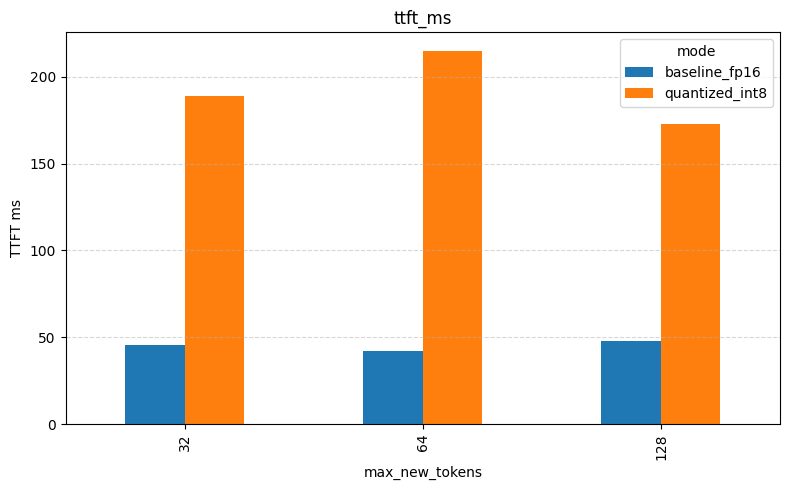

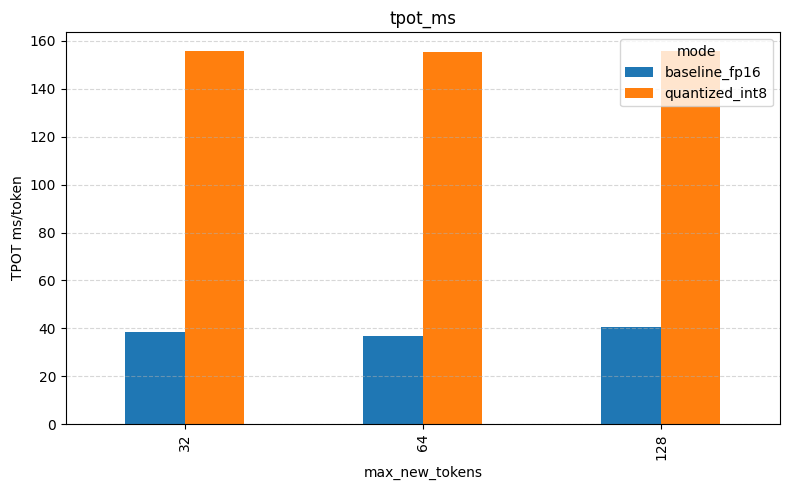

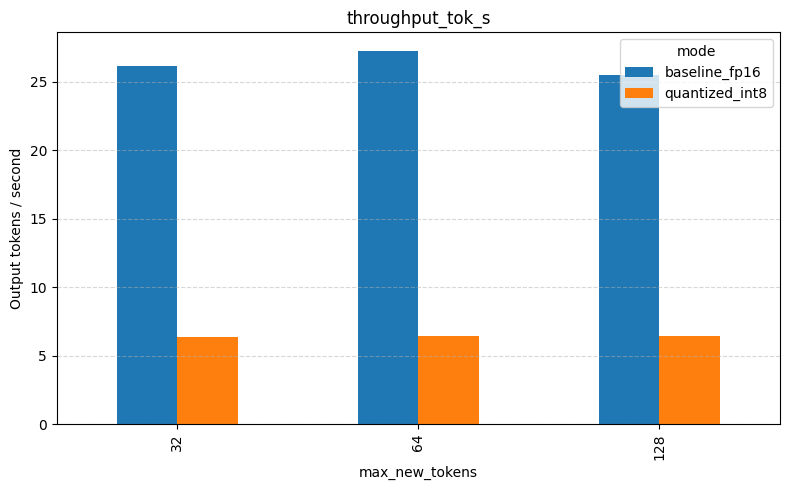

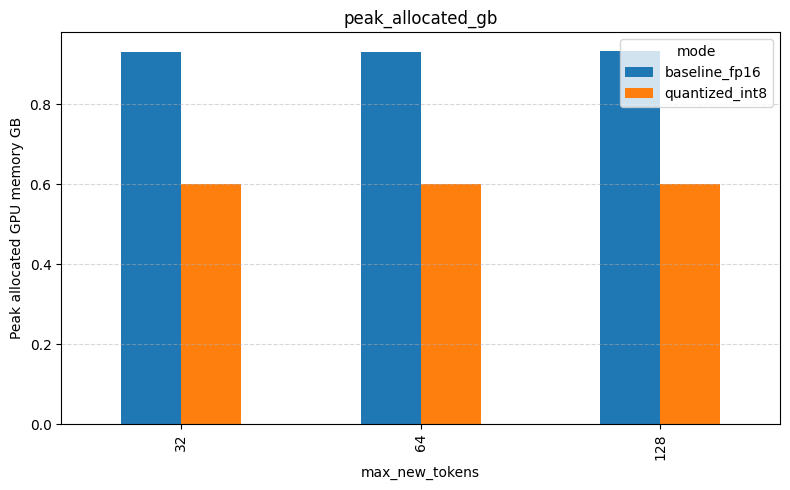

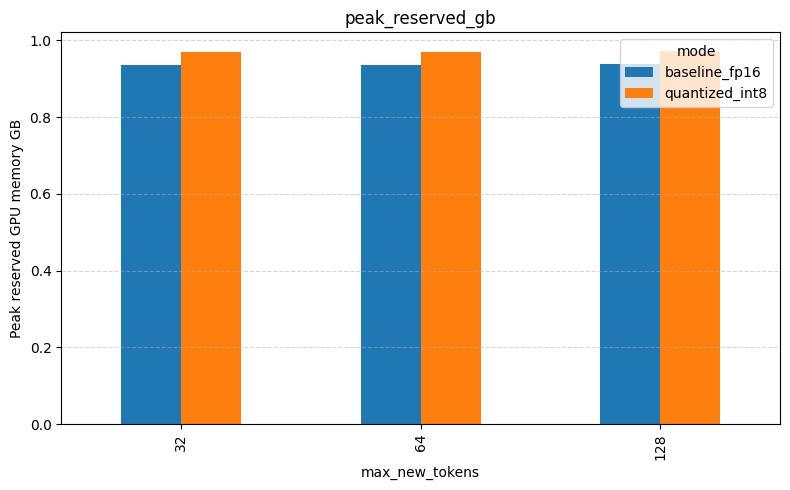

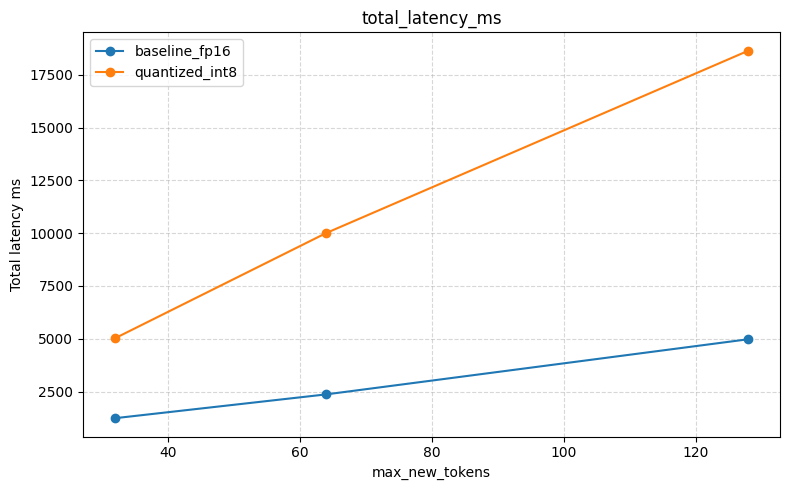


Plots saved to: /content/day24_quant_results


In [11]:
all_results = []

# ============================================================
# 1. FP16 baseline
# ============================================================

baseline_results = benchmark_one_mode(
    model_name=MODEL_NAME,
    quantization="fp16",
    mode_name="baseline_fp16",
)

all_results.extend(baseline_results)
save_results_to_csv(all_results, CSV_PATH)


# ============================================================
# 2. INT8 quantized
# ============================================================

int8_results = benchmark_one_mode(
    model_name=MODEL_NAME,
    quantization="int8",
    mode_name="quantized_int8",
)

all_results.extend(int8_results)
save_results_to_csv(all_results, CSV_PATH)


# ============================================================
# 3. Plot
# ============================================================

make_all_plots(CSV_PATH)

## Summary Table

In [12]:
df = pd.read_csv(CSV_PATH)

summary = (
    df.groupby("mode")[
        [
            "ttft_ms",
            "total_latency_ms",
            "tpot_ms",
            "throughput_tok_s",
            "peak_allocated_gb",
            "peak_reserved_gb",
        ]
    ]
    .mean()
    .reset_index()
)

summary

,mode,ttft_ms,total_latency_ms,tpot_ms,throughput_tok_s,peak_allocated_gb,peak_reserved_gb
0,baseline_fp16,45.225410,2860.476542,38.639682,26.281376,0.932681,0.936198
1,quantized_int8,192.009135,11220.718416,155.700663,6.401555,0.601120,0.971191


## Show Detailed Results

In [13]:
df[
    [
        "mode",
        "quantization",
        "prompt_id",
        "max_new_tokens",
        "input_tokens",
        "output_tokens",
        "ttft_ms",
        "tpot_ms",
        "throughput_tok_s",
        "peak_allocated_gb",
        "quality_note",
    ]
]

,mode,quantization,prompt_id,max_new_tokens,input_tokens,output_tokens,ttft_ms,tpot_ms,throughput_tok_s,peak_allocated_gb,quality_note
0,baseline_fp16,fp16,0,32,33,32,45.202876,41.296210,24.491487,0.931871,manual review needed
1,baseline_fp16,fp16,1,32,28,32,43.736942,35.764454,27.772625,0.931824,manual review needed
2,baseline_fp16,fp16,2,32,33,32,45.507705,36.226244,27.392110,0.931871,manual review needed
3,baseline_fp16,fp16,3,32,33,32,48.044817,40.609415,24.784862,0.931871,manual review needed
4,baseline_fp16,fp16,0,64,33,64,41.437246,35.278400,28.273598,0.932461,manual review needed
5,baseline_fp16,fp16,1,64,28,64,45.170535,37.427726,26.733274,0.932360,manual review needed
6,baseline_fp16,fp16,2,64,33,64,41.154685,38.002515,26.638362,0.932461,manual review needed
7,baseline_fp16,fp16,3,64,33,64,41.146137,36.798154,27.300701,0.932461,manual review needed
8,baseline_fp16,fp16,0,128,33,128,57.077388,52.762878,19.699435,0.933900,manual review needed
9,baseline_fp16,fp16,1,128,28,128,45.673633,36.244599,27.619843,0.933799,manual review needed


In [14]:
for i, row in df.iterrows():
    print("=" * 100)
    print("Mode:", row["mode"])
    print("Prompt ID:", row["prompt_id"])
    print("Max new tokens:", row["max_new_tokens"])
    print("Output:")
    print(row["output_text"])
    print()

Mode: baseline_fp16
Prompt ID: 0
Max new tokens: 32
Output:
Quantization is the process of reducing the precision or scale of a machine learning model's output to make it more efficient and faster to train on. In the context

Mode: baseline_fp16
Prompt ID: 1
Max new tokens: 32
Output:
Quantization is a process used in machine learning and deep learning to convert floating-point numbers into integers, which reduces the amount of memory required by the model. This

Mode: baseline_fp16
Prompt ID: 2
Max new tokens: 32
Output:
FP16 (Float-16) and INT8 (Integer-8) are two different formats used in deep learning to represent floating-point numbers, with

Mode: baseline_fp16
Prompt ID: 3
Max new tokens: 32
Output:
Latency refers to the time it takes for data to travel from the source to the destination, while output quality refers to how well the data is presented or displayed

Mode: baseline_fp16
Prompt ID: 0
Max new tokens: 64
Output:
Quantization is the process of reducing the precision or 